
=== VERSION 2: SGD with Sigmoid (With Normalization) ===
Loading MNIST data...


C:\Users\User\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Training data shape: (60000, 784)
Test data shape: (10000, 784)
Data Statistics:
  Mean pixel value: 0.1307
  Standard deviation: 0.3081

Training with Sigmoid activation (With Normalization)...
Epoch 1/5:
  Loss: 0.5912, Accuracy: 0.8568
Epoch 2/5:
  Loss: 0.2898, Accuracy: 0.9169
Epoch 3/5:
  Loss: 0.2420, Accuracy: 0.9305
Epoch 4/5:
  Loss: 0.2097, Accuracy: 0.9401
Epoch 5/5:
  Loss: 0.1856, Accuracy: 0.9481


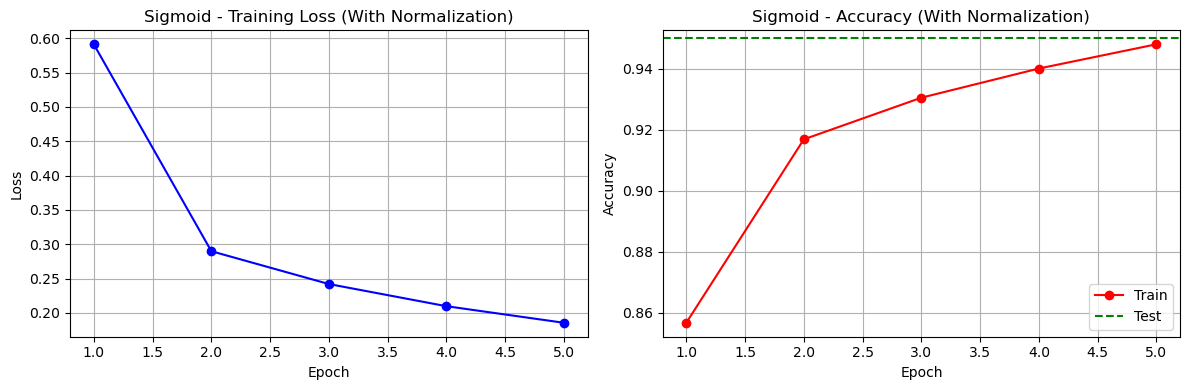


=== RESULTS: Sigmoid (With Normalization) ===
Data Statistics:
  Mean pixel value: 0.1307
  Standard deviation: 0.3081
Epoch 1: Loss = 0.5912, Train Acc = 0.8568
Epoch 2: Loss = 0.2898, Train Acc = 0.9169
Epoch 3: Loss = 0.2420, Train Acc = 0.9305
Epoch 4: Loss = 0.2097, Train Acc = 0.9401
Epoch 5: Loss = 0.1856, Train Acc = 0.9481
Final Test Accuracy: 0.9500


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

print("\n" + "="*60)
print("=== VERSION 2: SGD with Sigmoid (With Normalization) ===")
print("="*60)

# Load MNIST data
print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Split into train and test
X_train = X[:60000] / 255.0
X_test = X[60000:] / 255.0
y_train = y[:60000]
y_test = y[60000:]

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Normalize data
train_mean = np.mean(X_train)
train_std = np.std(X_train)
X_train_normalized = (X_train - train_mean) / train_std
X_test_normalized = (X_test - train_mean) / train_std

print(f"Data Statistics:")
print(f"  Mean pixel value: {train_mean:.4f}")
print(f"  Standard deviation: {train_std:.4f}")

# Convert labels to one-hot encoding
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# Network parameters
d = 784  # input dimension
h = 128  # hidden units
k = 10   # output classes

# Initialize weights (Xavier initialization for sigmoid)
W1 = np.random.uniform(-1/np.sqrt(d), 1/np.sqrt(d), (h, d))
W2 = np.random.uniform(-1/np.sqrt(h), 1/np.sqrt(h), (k, h))

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    return x * (1 - x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

# Training parameters
learning_rate = 1e-3
batch_size = 1
epochs = 5

# Storage for metrics
train_losses_norm = []
train_accuracies_norm = []

print("\nTraining with Sigmoid activation (With Normalization)...")
for epoch in range(epochs):
    epoch_loss = 0
    epoch_correct = 0
    num_batches = 0
    
    # Shuffle training data
    indices = np.random.permutation(len(X_train_normalized))
    X_epoch = X_train_normalized[indices]
    y_epoch = y_train_onehot[indices]
    y_labels_epoch = y_train[indices]
    
    for i in range(0, len(X_epoch), batch_size):
        x = X_epoch[i].reshape(-1, 1)
        y = y_epoch[i].reshape(-1, 1)
        y_label = y_labels_epoch[i]
        
        # Forward pass
        a1 = W1 @ x
        h1 = sigmoid(a1)
        a2 = W2 @ h1
        y_hat = softmax(a2)
        
        # Compute loss and accuracy
        loss = -np.sum(y * np.log(y_hat + 1e-8))
        epoch_loss += loss
        predicted_class = np.argmax(y_hat)
        if predicted_class == y_label:
            epoch_correct += 1
        
        # Backward pass
        delta2 = y_hat - y
        dW2 = delta2 @ h1.T
        
        delta_h = W2.T @ delta2
        sig_deriv = sigmoid_derivative(h1)
        delta1 = delta_h * sig_deriv
        dW1 = delta1 @ x.T
        
        # Update weights
        W2 -= learning_rate * dW2
        W1 -= learning_rate * dW1
        
        num_batches += 1
    
    # Epoch statistics
    avg_loss = epoch_loss / num_batches
    accuracy = epoch_correct / num_batches
    
    train_losses_norm.append(avg_loss)
    train_accuracies_norm.append(accuracy)
    
    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"  Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

# Test accuracy
test_correct_norm = 0
for i in range(len(X_test_normalized)):
    x = X_test_normalized[i].reshape(-1, 1)
    y_label = y_test[i]
    
    a1 = W1 @ x
    h1 = sigmoid(a1)
    a2 = W2 @ h1
    y_hat = softmax(a2)
    
    predicted_class = np.argmax(y_hat)
    if predicted_class == y_label:
        test_correct_norm += 1

test_accuracy_norm = test_correct_norm / len(X_test_normalized)

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses_norm, 'b-o')
plt.title('Sigmoid - Training Loss (With Normalization)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies_norm, 'r-o', label='Train')
plt.axhline(y=test_accuracy_norm, color='g', linestyle='--', label='Test')
plt.title('Sigmoid - Accuracy (With Normalization)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== RESULTS: Sigmoid (With Normalization) ===")
print(f"Data Statistics:")
print(f"  Mean pixel value: {train_mean:.4f}")
print(f"  Standard deviation: {train_std:.4f}")
for epoch in range(epochs):
    print(f"Epoch {epoch+1}: Loss = {train_losses_norm[epoch]:.4f}, Train Acc = {train_accuracies_norm[epoch]:.4f}")
print(f"Final Test Accuracy: {test_accuracy_norm:.4f}")